# 04 · Persistence in LangGraph - threads, checkpoints & time travel

> Workshop module · builds on last class (`agent-builder: thinking in langgraph`).
> Today we make our graphs **remember**.

**The big idea:** a plain LangGraph run is *stateless* - when `invoke()` returns, the state is gone.
Attach a **checkpointer** and LangGraph saves a snapshot of the state at **every step**, keyed by a
**`thread_id`**. That single change unlocks:

- 🧠 **Memory** - multi-turn conversations that remember earlier turns
- 👤 **Human-in-the-loop** - pause, inspect, approve, resume
- ⏪ **Time travel** - replay or fork from any past step
- 🛟 **Fault tolerance** - resume from the last good step after a crash

We'll go slowly with lots of tiny, runnable demos.

![checkpoints](images/checkpoints.jpg)

> ⏸️ **Scope for today:** short-term memory via the **checkpointer + thread**.
> The *long-term* **Memory Store** (cross-thread memory) is the *next* session - we stop right before it.

## 0 · Setup

We load the OpenAI key from your local `.env` (already in this folder).

In [1]:
import os
# --- Load API keys from the project .env, no matter how/where Jupyter was started ---
_ENV_PATH = "/Users/datasense/Desktop/langgrapgh-agent/.env"
for _line in open(_ENV_PATH):
    _line = _line.strip()
    if _line and not _line.startswith("#") and "=" in _line:
        _k, _v = _line.split("=", 1)
        os.environ[_k.strip()] = _v.strip().strip('"').strip("'")
print("Loaded keys:", [k for k in ("OPENAI_API_KEY", "TAVILY_API_KEY", "SERPAPI_API_KEY") if os.getenv(k)])
  # reads .env in this folder
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY missing from .env"
print("OpenAI key loaded")

Loaded keys: ['OPENAI_API_KEY', 'TAVILY_API_KEY', 'SERPAPI_API_KEY']
OpenAI key loaded


## 1 · A tiny graph (no memory yet)

A minimal 2-node graph. Notice the **state shape**:

- `foo` is a plain string → each write **overwrites** it.
- `bar` is `Annotated[list, add]` → each write is **appended** (a *reducer*).

The reducer is what makes accumulation visible later.

In [2]:
from IPython.display import Image, display

def show(graph):
    "Render a LangGraph as an inline mermaid PNG (falls back to ASCII if offline)."
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        print(graph.get_graph().draw_ascii())

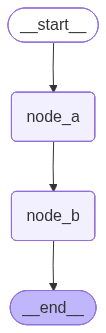

In [3]:
from typing import Annotated
from typing_extensions import TypedDict
from operator import add
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    foo: str
    bar: Annotated[list[str], add]   # reducer: appends instead of overwriting

def node_a(state: State):
    return {"foo": "a", "bar": ["a"]}

def node_b(state: State):
    return {"foo": "b", "bar": ["b"]}

builder = StateGraph(State)
builder.add_node(node_a)
builder.add_node(node_b)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", END)

graph_no_memory = builder.compile()
show(graph_no_memory)

## 2 · Add a checkpointer + a thread

We compile the **same** graph with an `InMemorySaver` checkpointer.

The only thing we add at call time is a **`thread_id`** inside `config["configurable"]`.
Think of a thread as *one conversation / one session*. The checkpointer uses it as the primary key
for storing and looking up snapshots.

In [4]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "1"}}   # <-- the thread
result = graph.invoke({"foo": "", "bar": []}, config)
print("final state:", result)

final state: {'foo': 'b', 'bar': ['a', 'b']}


## 3 · Read the saved state: `get_state`

`get_state(config)` returns a **`StateSnapshot`** - the latest checkpoint for this thread.

Key fields to point out to students:

| field | meaning |
|---|---|
| `values` | the actual state at this checkpoint |
| `next` | which node(s) run next; **empty `()` = finished** |
| `config` | identifies the checkpoint (`thread_id`, `checkpoint_id`) |
| `metadata` | `step` counter, `source`, and the `writes` that produced it |
| `created_at` | timestamp |
| `parent_config` | the previous checkpoint (the chain backwards) |

In [5]:
snap = graph.get_state(config)
print("values   :", snap.values)
print("next     :", snap.next, "  <- empty tuple means the run is complete")
print("step     :", snap.metadata["step"])
print("checkpoint:", snap.config["configurable"]["checkpoint_id"])

values   : {'foo': 'b', 'bar': ['a', 'b']}
next     : ()   <- empty tuple means the run is complete
step     : 2
checkpoint: 1f15bc40-ed58-616e-8002-01c46b5416cb


## 4 · The whole story: `get_state_history`

Every **super-step** (one "tick" where scheduled nodes run) writes a checkpoint.
`get_state_history` returns them **newest → oldest**, so you can see the graph's entire timeline.

![get_state](images/get_state.jpg)

In [6]:
history = list(graph.get_state_history(config))
print(f"{len(history)} checkpoints saved for thread '1':\n")
for snap in history:
    print(f"step {snap.metadata['step']:>2} | next={str(snap.next):<12} | values={snap.values}")

4 checkpoints saved for thread '1':

step  2 | next=()           | values={'foo': 'b', 'bar': ['a', 'b']}
step  1 | next=('node_b',)  | values={'foo': 'a', 'bar': ['a']}
step  0 | next=('node_a',)  | values={'foo': '', 'bar': []}
step -1 | next=('__start__',) | values={'bar': []}


**Read it bottom-up:** `step -1` is the raw input, `step 0` runs `__start__`, `step 1` runs `node_a`,
`step 2` runs `node_b` and finishes (`next=()`). Each row is a point we can jump back to later.

## 5 · Why the thread matters - accumulation vs isolation

Two tiny experiments that make "thread = session" click.

**5a. Same thread again** → state persisted, so the `bar` reducer keeps appending.

In [7]:
# invoke thread "1" a SECOND time
graph.invoke({"foo": "", "bar": []}, {"configurable": {"thread_id": "1"}})
print("thread '1' bar:", graph.get_state({'configurable': {'thread_id': '1'}}).values["bar"])
# -> ['a','b','a','b']  the new run appended to what was already there

thread '1' bar: ['a', 'b', 'a', 'b']


In [8]:
# a DIFFERENT thread starts fresh - fully isolated
graph.invoke({"foo": "", "bar": []}, {"configurable": {"thread_id": "2"}})
print("thread '2' bar:", graph.get_state({'configurable': {'thread_id': '2'}}).values["bar"])
# -> ['a','b']  thread 2 knows nothing about thread 1

thread '2' bar: ['a', 'b']


> 🔑 **Takeaway:** the checkpointer is shared, but each `thread_id` has its own independent timeline.
> Same thread = continue; new thread = blank slate.

## 6 · The "aha": a chatbot that remembers

Now the real payoff. We use the built-in `MessagesState` (its `messages` field has an
`add_messages` reducer, so the conversation **accumulates**). With a checkpointer, the model sees the
full history on every turn - *for free*.

In [9]:
from langgraph.graph import MessagesState
from langchain.chat_models import init_chat_model

llm = init_chat_model("openai:gpt-4o-mini", temperature=0)

def chat(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"])]}

chat_builder = StateGraph(MessagesState)
chat_builder.add_node("chat", chat)
chat_builder.add_edge(START, "chat")
chat_builder.add_edge("chat", END)

bot = chat_builder.compile(checkpointer=InMemorySaver())
print("chatbot compiled")

chatbot compiled


In [10]:
alice = {"configurable": {"thread_id": "alice"}}

r1 = bot.invoke({"messages": [{"role": "user", "content": "Hi! My name is Satvik and I love LangGraph."}]}, alice)
print("turn 1:", r1["messages"][-1].content)

r2 = bot.invoke({"messages": [{"role": "user", "content": "What's my name and what do I love?"}]}, alice)
print("turn 2:", r2["messages"][-1].content, "  <-- remembered, no re-sending history!")

turn 1: Hi Satvik! It's great to hear that you love LangGraph! What do you enjoy most about it?


turn 2: Your name is Satvik, and you love LangGraph!   <-- remembered, no re-sending history!


In [11]:
# different thread = different person = no memory of Satvik
bob = {"configurable": {"thread_id": "bob"}}
r = bot.invoke({"messages": [{"role": "user", "content": "What's my name?"}]}, bob)
print("bob's thread:", r["messages"][-1].content)

bob's thread: I'm sorry, but I don't have access to personal information about you unless you've shared it in this conversation. How can I assist you today?


In [12]:
# peek under the hood: how many messages are stored on alice's thread?
msgs = bot.get_state(alice).values["messages"]
print(f"alice thread holds {len(msgs)} messages:")
for m in msgs:
    print(f"  {m.type:>9}: {m.content[:60]}")

alice thread holds 4 messages:
      human: Hi! My name is Satvik and I love LangGraph.
         ai: Hi Satvik! It's great to hear that you love LangGraph! What 
      human: What's my name and what do I love?
         ai: Your name is Satvik, and you love LangGraph!


## 7 · Time travel - replay from a past checkpoint

Because every step is saved, we can **resume the graph from any past checkpoint**.
Grab a `checkpoint_id` from the history, put it in the config, and invoke with `None` as input -
LangGraph picks up exactly there and replays forward.

![replay](images/re_play.png)

In [13]:
# use our first graph (thread "1"). Find the checkpoint taken right BEFORE node_b ran.
hist = list(graph.get_state_history({"configurable": {"thread_id": "1"}}))
before_b = next(s for s in hist if s.next == ("node_b",))
print("resuming from step", before_b.metadata["step"], "where next =", before_b.next)

# invoke with input=None and that checkpoint's config -> replays node_b forward
resumed = graph.invoke(None, before_b.config)
print("replayed result:", resumed)

resuming from step 5 where next = ('node_b',)
replayed result: {'foo': 'b', 'bar': ['a', 'b', 'a', 'b']}


## 8 · Forking - `update_state`

Time travel becomes powerful when you **change** the past. `update_state` writes a *new* checkpoint
on top of a chosen one - a branch in the timeline. Great for "what if the state had been different?"
and for human edits / approvals.

In [14]:
fork_cfg = {"configurable": {"thread_id": "fork-demo"}}
graph.invoke({"foo": "", "bar": []}, fork_cfg)
print("before update:", graph.get_state(fork_cfg).values)

# manually edit the state -> creates a NEW checkpoint (note metadata source='update')
graph.update_state(fork_cfg, {"foo": "EDITED", "bar": ["manual"]})
print("after  update:", graph.get_state(fork_cfg).values)
print("source of newest checkpoint:", graph.get_state(fork_cfg).metadata["source"])

before update: {'foo': 'b', 'bar': ['a', 'b']}
after  update: {'foo': 'EDITED', 'bar': ['a', 'b', 'manual']}
source of newest checkpoint: update


## 9 · Durable memory across restarts - `SqliteSaver`

`InMemorySaver` vanishes when the kernel dies. For anything real you want a checkpointer backed by a
database. `SqliteSaver` writes to a file, so state **survives a process restart**.
(In production you'd swap in `PostgresSaver` - same interface.)

![checkpoints full story](images/checkpoints_full_story.jpg)

In [15]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

# write some state to a file-backed checkpointer
conn = sqlite3.connect("workshop_checkpoints.sqlite", check_same_thread=False)
durable_graph = builder.compile(checkpointer=SqliteSaver(conn))
durable_graph.invoke({"foo": "", "bar": []}, {"configurable": {"thread_id": "persist-me"}})
print("wrote state to workshop_checkpoints.sqlite")

wrote state to workshop_checkpoints.sqlite


In [16]:
# --- simulate a fresh process: brand new connection + saver, same file ---
conn2 = sqlite3.connect("workshop_checkpoints.sqlite", check_same_thread=False)
reloaded = builder.compile(checkpointer=SqliteSaver(conn2))

snap = reloaded.get_state({"configurable": {"thread_id": "persist-me"}})
print("recovered from disk after 'restart':", snap.values)

recovered from disk after 'restart': {'foo': 'b', 'bar': ['a', 'b', 'a', 'b', 'a', 'b']}


## Recap

| concept | what it gives you |
|---|---|
| **`thread_id`** | the key for one session's timeline |
| **checkpointer** (`InMemorySaver`, `SqliteSaver`, `PostgresSaver`) | saves a snapshot every super-step |
| **`get_state`** | the latest `StateSnapshot` (`values`, `next`, `metadata`...) |
| **`get_state_history`** | the full newest→oldest timeline |
| **replay** (`invoke(None, checkpoint_cfg)`) | resume from any past step |
| **`update_state`** | edit/fork the timeline (human-in-the-loop) |

**Mental model:** *checkpointer = the disk, `thread_id` = the file name, checkpoint = a saved version.*

### ⏭️ Next session
**Memory Store** - long-term memory that is **shared across threads** (e.g. remember a user's food
preference in *every* conversation, not just one). `store.put(...)` / `store.search(...)`, namespaces,
and semantic search. That's where we pick up next time.

### 🏋️ Exercises
1. Add a third thread and confirm isolation.
2. In the chatbot, find the `checkpoint_id` after turn 1 and replay turn 2 from it.
3. Use `update_state` on the chatbot to inject a fake assistant message, then continue the conversation.